# Clustering Assignments

## 1. K-Means Clustering

In [2]:
# 1. Read in the cereal.csv file
import pandas as pd
df = pd.read_csv("../Data/cereal.csv")

In [3]:
# 2. Prep the data by dropping the name and manufacturer columns: aka only keep the numeric columns
df.head()
df.drop(columns=["Cereal Name","Manufacturer"],inplace=True);

In [4]:
# 3. Fit a K-Means Clustering model with 2 clusters
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, n_init="auto", random_state=0)
kmeans.fit(df)

KMeans(n_clusters=2, random_state=0)

In [14]:
kmeans_labels = pd.DataFrame(kmeans.labels_)
kmeans_labels.head()

,0
0,0
1,1
2,0
3,0
4,1


<Axes: >

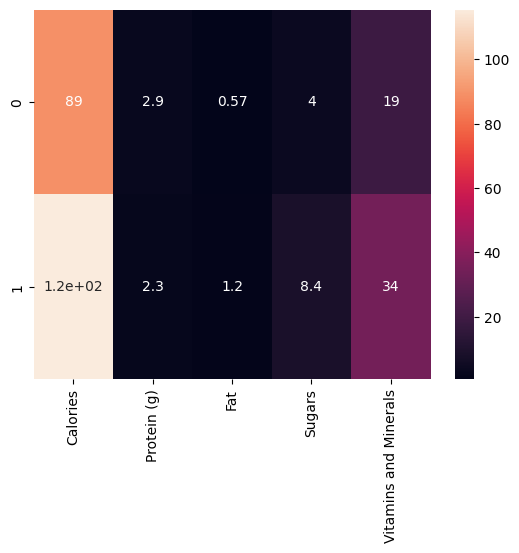

In [15]:
import seaborn as sns
sns.heatmap(kmeans.cluster_centers_,xticklabels=df.columns,annot=True)

In [ ]:
#the only thing distinguishing these two groups is the vitamins content and the calories

## 2. Inertia Plot

In [18]:
# 1. Write a loop to fit K-Means Clustering models with 2 to 15 clusters
inertia = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k,n_init="auto",random_state=0)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

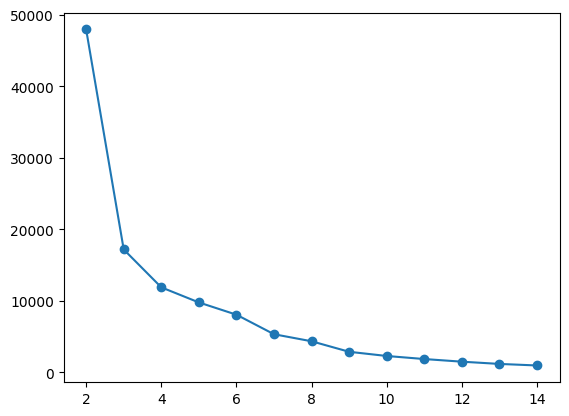

In [25]:
# 2. Create a plot with the number of clusters on the x-axis and the inertia on the y-axis
import matplotlib.pyplot as plt
plt.plot(range(2,15),inertia,marker="o")

In [ ]:
# 3. Identify the elbow of the plot
#elbow = 3

In [5]:
# 4. Fit a K-Means Clustering model on the specific number of clusters at the elbow
kmeans3 = KMeans(n_clusters=3,n_init="auto",random_state=0)
kmeans3.fit(df)

KMeans(n_clusters=3, random_state=0)

<Axes: >

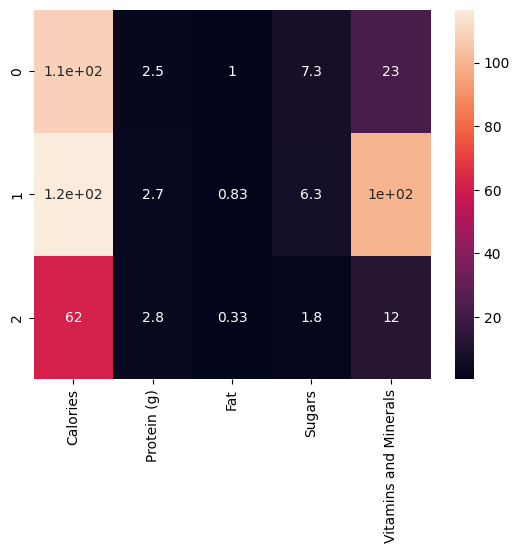

In [8]:
# 5. Interpret the cluster centers using a heat map
import seaborn as sns
dataframe = pd.DataFrame(kmeans3.cluster_centers_,columns=df.columns)
sns.heatmap(dataframe,annot=True)

In [ ]:
#first type of cereal is high in calories, sugar and low in vitamins
#second type is high in calories, sugar and vitamins
#third is low in calories sugar and vitamins

## 3. Tune the K-Means Model

In [11]:
# 1. Remove the ”Fat” column
df.head()
df_no_fat = df[["Calories","Protein (g)","Sugars","Vitamins and Minerals"]]


In [12]:
# 2. Standardize the remaining columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_no_fat_scaled = scaler.fit_transform(df_no_fat)
df_no_fat_scaled = pd.DataFrame(df_no_fat_scaled,columns=["Calories","Protein (g)","Sugars","Vitamins and Minerals"])
df_no_fat_scaled.head()

,Calories,Protein (g),Sugars,Vitamins and Minerals
0,-1.940286,1.387392,-0.173586,-0.149270
1,0.789394,0.462464,0.277129,-1.253871
2,-1.940286,1.387392,-0.398944,-0.149270
3,-3.032158,1.387392,-1.525731,-0.149270
4,0.243458,-0.462464,0.277129,-0.149270


In [47]:
# 3a. Write a loop to fit K-Means Clustering models with 2 to 15 clusters
inertia = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k,n_init="auto",random_state=0)
    kmeans.fit(df_no_fat_scaled)
    inertia.append(kmeans.inertia_)

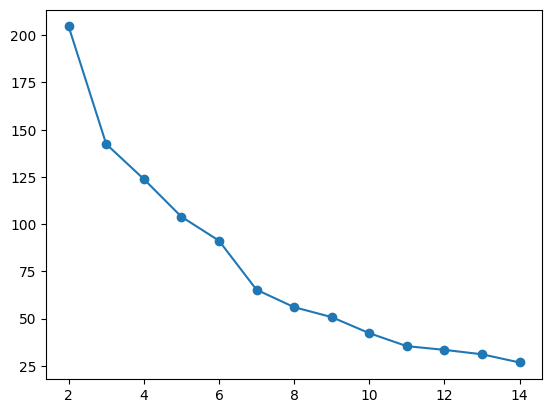

In [57]:
# 3b. Create a plot with the number of clusters on the x-axis and the inertia on the y-axis
plt.plot(range(2,15),inertia,marker="o");

In [ ]:
# 3c. Identify the elbow of the plot
#elbo at 7

In [13]:
# 3d. Fit a K-Means Clustering model on the specific number of clusters at the elbow
kmeans6 = KMeans(n_clusters=6, n_init="auto",random_state=0)
kmeans6.fit(df_no_fat_scaled)

KMeans(n_clusters=6, random_state=0)

<Axes: >

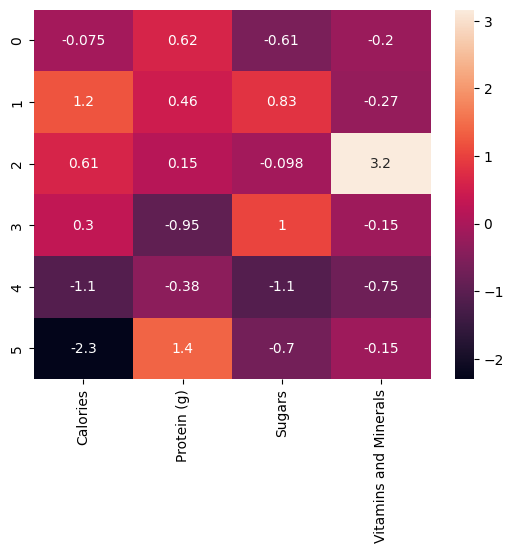

In [14]:
# 3e. Interpret the cluster centers using a heat map
kmeans6_dataframe =pd.DataFrame(kmeans6.cluster_centers_,columns=df_no_fat.columns)
sns.heatmap(kmeans6_dataframe,annot=True)

In [ ]:
#0: high in protein, low in sugar
#1: high in calories, protein and sugar
#2: high in calories, vitamins and minerals
#3: low in protein, high in sugar
#4: low in calories, sugar and vitamins and minerals
#5: low in calories and sugar, high in protein

## 4. Select the Best K-Means Model

In [25]:
# 1. Label each row in your original data set with a cluster name from the unstandardized data model and a cluster name from standardized data model
kmeans3_dict = {0: "high in calories, sugar and low in vitamins", 1:"high in calories, sugar and vitamins",2:" low in calories sugar and vitamins"}
kmeans3_labels = pd.Series(kmeans3.labels_,name="kmeans3").map(kmeans3_dict)
kmeans6_dict = {0: "high in protein, low in sugar", 1: "high in calories, protein and sugar", 2: "high in calories, vitamins and minerals", 3: "low in protein, high in sugar", 4: "low in calories, sugar and vitamins and minerals", 5: "low in calories and sugar, high in protein"}
kmeans6_labels = pd.Series(kmeans6.labels_,name="kmeans6").map(kmeans6_dict)
df_labeled = pd.concat([df,kmeans3_labels,kmeans6_labels],axis=1)
df_labeled.head()

,Calories,Protein (g),Fat,Sugars,Vitamins and Minerals,kmeans3,kmeans6
0,70,4,1,6,25,low in calories sugar and vitamins,"low in calories and sugar, high in protein"
1,120,3,5,8,0,"high in calories, sugar and low in vitamins","high in calories, protein and sugar"
2,70,4,1,5,25,low in calories sugar and vitamins,"low in calories and sugar, high in protein"
3,50,4,0,0,25,low in calories sugar and vitamins,"low in calories and sugar, high in protein"
4,110,2,2,8,25,"high in calories, sugar and low in vitamins","low in protein, high in sugar"


In [34]:
pd.Series(kmeans3.labels_,name="kmeans3").map(kmeans3_dict).value_counts()


kmeans3
high in calories, sugar and low in vitamins    62
 low in calories sugar and vitamins             6
high in calories, sugar and vitamins            6
Name: count, dtype: int64

In [35]:
pd.Series(kmeans6.labels_,name="kmeans6").map(kmeans6_dict).value_counts()

kmeans6
high in protein, low in sugar                       24
low in protein, high in sugar                       21
low in calories, sugar and vitamins and minerals    11
high in calories, protein and sugar                  9
high in calories, vitamins and minerals              6
low in calories and sugar, high in protein           3
Name: count, dtype: int64

In [37]:
# 2. Look at the number of cereals that fall into each cluster
df_labeled.groupby(["kmeans3","kmeans6"])[["Calories","Protein (g)","Fat","Sugars","Vitamins and Minerals"]].mean()

Calories  \
kmeans3                                     kmeans6                                                        
 low in calories sugar and vitamins         low in calories and sugar, high in protein         63.333333   
                                            low in calories, sugar and vitamins and minerals   60.000000   
high in calories, sugar and low in vitamins high in calories, protein and sugar               127.777778   
                                            high in protein, low in sugar                     104.166667   
                                            low in calories, sugar and vitamins and minerals   95.000000   
                                            low in protein, high in sugar                     110.952381   
high in calories, sugar and vitamins        high in calories, vitamins and minerals           116.666667   

                                                                                              Protein (g)  \
kmeans3                                     kmeans6                                                         
 low in calories sugar and vitamins         low in calories and sugar, high in protein           4.000000   
                                            low in calories, sugar and vitamins and minerals     1.666667   
high in calories, sugar and low in vitamins high in calories, protein and sugar                  3.000000   
                                            high in protein, low in sugar                        3.166667   
                                            low in calories, sugar and vitamins and minerals     2.250000   
                                            low in protein, high in sugar                        1.476190   
high in calories, sugar and vitamins        high in calories, vitamins and minerals              2.666667   

                                                                                                   Fat  \
kmeans3                                     kmeans6                                                      
 low in calories sugar and vitamins         low in calories and sugar, high in protein        0.666667   
                                            low in calories, sugar and vitamins and minerals  0.000000   
high in calories, sugar and low in vitamins high in calories, protein and sugar               1.777778   
                                            high in protein, low in sugar                     1.000000   
                                            low in calories, sugar and vitamins and minerals  0.125000   
                                            low in protein, high in sugar                     1.047619   
high in calories, sugar and vitamins        high in calories, vitamins and minerals           0.833333   

                                                                                                 Sugars  \
kmeans3                                     kmeans6                                                       
 low in calories sugar and vitamins         low in calories and sugar, high in protein         3.666667   
                                            low in calories, sugar and vitamins and minerals   0.000000   
high in calories, sugar and low in vitamins high in calories, protein and sugar               10.444444   
                                            high in protein, low in sugar                      4.083333   
                                            low in calories, sugar and vitamins and minerals   2.625000   
                                            low in protein, high in sugar                     11.380952   
high in calories, sugar and vitamins        high in calories, vitamins and minerals            6.333333   

                                                                                              Vitamins and Minerals  
kmeans3                                     kmeans6                                                     

In [ ]:
# 3. Decide on the best model for our client
#n=6 seems to segment the cereals better, since kmeans3 puts most cereals in one group and does not capture as much of the differences beween them

In [ ]:
# 4. Recommend a specific number of displays
#I would recommend 5 displays, combining high in protein, low in sugar and low in calories, sugar and vitamins and minerals in the second group, since they are pretty similar